<a href="https://colab.research.google.com/github/in-the-neon-sunrise/mfti-alpha-test-task/blob/main/mfti_alpha_test_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.3 MB/s eta 0:00:00


# подготовка

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr

pd.set_option('display.max_columns', None)

train = pd.read_csv('/content/train_apps.csv')

print(train.shape)
train.head()

(21036, 28)


,front_id,decision_day,loan_amount_last,overdraft_limit_min,overdraft_limit_max,offered_rate,cb_rate,corp_credit_products,sum_deb_ul_90,sum_deb_ul_30,cnt_deb_loan_90,cnt_deb_ul_ip_90,cnt_deb_ul_ip_30,balance_rur_amt_30_min,cnt_cred_loan_90,loan_rev_max_start_non_fin,loan_rev_min_start_fin,app_term_mean_360,overdraft_app_term_max_360,days_from_authperson_registration,fl_hdb_bki_total_active_products,corp_list,count_all_corp_dashboard_events,p75_time_spent_minutes,sum_deb_investment_90,db_group_last,fl_adminarea,target_value
0,127345,2024-02-01,1.339991,-1.847954,-1.586546,1.774424,-0.400695,NaN,NaN,NaN,NaN,NaN,NaN,-5.561599,NaN,NaN,NaN,1.767094,NaN,NaN,NaN,NaN,NaN,NaN,NaN,lombard,NaN,0.0
1,127209,2024-02-01,-2.808489,-3.155914,-2.618329,1.774424,-0.400695,0.842771,NaN,NaN,0.000000,-4.466656,-0.736050,1.466815,0.000000,NaN,NaN,-0.504888,NaN,NaN,NaN,-0.862289,-3.400318,-0.780786,NaN,inn_scoring,NaN,0.0
2,272776,2024-02-01,2.185431,3.167063,2.369547,-0.709770,-0.400695,0.000000,0.834373,4.897257,0.000000,5.291707,0.872047,4.041974,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.168810,3.015012,0.554064,NaN,NaN,NaN,0.0
3,127210,2024-02-01,-1.468500,-2.595950,-2.176602,1.774424,-0.400695,NaN,NaN,NaN,NaN,NaN,NaN,-3.322507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,164500,2024-02-01,0.845440,4.559196,3.467730,-2.484194,-0.400695,0.000000,-0.518122,-3.435251,2.999207,-1.373655,-0.118673,4.324315,6.729738,NaN,NaN,NaN,NaN,1.067447,NaN,1.022327,1.506380,0.190096,NaN,NaN,NaN,0.0


In [ ]:
print(train.info())

train.describe().T

<class 'pandas.core.frame.DataFrame'>
Index: 21035 entries, 0 to 21034
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   front_id                           21035 non-null  int64  
 1   decision_day                       21035 non-null  object 
 2   loan_amount_last                   21035 non-null  float64
 3   overdraft_limit_min                21035 non-null  float64
 4   overdraft_limit_max                21035 non-null  float64
 5   offered_rate                       21035 non-null  float64
 6   corp_credit_products               12216 non-null  float64
 7   sum_deb_ul_90                      11702 non-null  float64
 8   sum_deb_ul_30                      10677 non-null  float64
 9   cnt_deb_loan_90                    15142 non-null  float64
 10  cnt_deb_ul_ip_90                   15297 non-null  float64
 11  cnt_deb_ul_ip_30                   14740 non-null  float64


,count,mean,std,min,25%,50%,75%,max
front_id,21035.0,204545.566722,56640.620520,102805.000000,155230.500000,216962.000000,250120.500000,280284.000000
loan_amount_last,21035.0,-0.100106,1.558161,-5.616959,-1.117611,0.000000,0.845440,3.030871
overdraft_limit_min,21035.0,-0.896146,2.610893,-8.378948,-2.981340,-1.472941,1.138327,5.211760
overdraft_limit_max,21035.0,-0.835713,2.059601,-6.738516,-2.480616,-1.290717,0.769180,3.982505
offered_rate,21035.0,1.802768,3.411519,-3.903733,-0.709770,0.709770,3.548848,8.162350
corp_credit_products,12216.0,0.503404,0.656780,0.000000,0.000000,0.000000,1.141372,2.445289
sum_deb_ul_90,11702.0,-0.112542,0.595164,-3.556551,-0.430591,-0.018332,0.311617,1.511046
sum_deb_ul_30,10677.0,-0.770146,3.347887,-19.350610,-2.689377,-0.365174,1.628917,8.808063
cnt_deb_loan_90,15142.0,1.413033,2.047795,0.000000,0.000000,0.000000,2.999207,12.001956
cnt_deb_ul_ip_90,15297.0,-1.337742,3.081684,-6.953811,-3.395496,-0.705855,0.964541,9.834125


In [ ]:
train['target_value'].value_counts()

,count
target_value,
0.0,20363
1.0,672


In [ ]:
missing = (
    train.isnull()
    .mean()
    .sort_values(ascending=False)
    * 100
)
missing = missing[missing > 0]
print(missing)

days_from_authperson_registration    52.926076
sum_deb_ul_30                        49.241740
sum_deb_ul_90                        44.368909
corp_list                            41.925362
corp_credit_products                 41.925362
count_all_corp_dashboard_events      41.925362
p75_time_spent_minutes               41.925362
app_term_mean_360                    38.507250
db_group_last                        38.507250
fl_adminarea                         38.369384
cnt_deb_ul_ip_30                     29.926313
balance_rur_amt_30_min               28.823390
cnt_deb_loan_90                      28.015213
cnt_cred_loan_90                     28.015213
cnt_deb_ul_ip_90                     27.278346
fl_hdb_bki_total_active_products     22.861897
dtype: float64


In [ ]:
target = 'target_value'

cat_cols = train.select_dtypes(include=['object']).columns.tolist()
num_cols = train.select_dtypes(include=np.number).columns.tolist()
num_cols.remove(target)

print("Categorical:")
print(cat_cols)

print("\nNumeric:")
print(len(num_cols))

Categorical:
['decision_day', 'db_group_last', 'fl_adminarea']

Numeric:
19


In [ ]:
corr_target = (
    train[num_cols + [target]]
    .corr()['target_value']
    .drop('target_value')
    .sort_values()
)

corr_target

,target_value
offered_rate,-0.116978
app_term_mean_360,-0.068820
balance_rur_amt_30_min,-0.059440
loan_amount_last,-0.049134
fl_hdb_bki_total_active_products,-0.020121
front_id,-0.011482
days_from_authperson_registration,0.013066
corp_credit_products,0.017288
corp_list,0.059473
p75_time_spent_minutes,0.075357


In [ ]:
spearman_corr = {}

for col in num_cols:
    corr, _ = spearmanr(train[col], train[target], nan_policy='omit')
    spearman_corr[col] = corr

spearman_corr = pd.Series(spearman_corr).sort_values()

spearman_corr

,0
offered_rate,-0.126785
app_term_mean_360,-0.085179
balance_rur_amt_30_min,-0.049822
loan_amount_last,-0.046831
fl_hdb_bki_total_active_products,-0.016911
front_id,-0.011453
corp_credit_products,0.020195
days_from_authperson_registration,0.020965
corp_list,0.065764
p75_time_spent_minutes,0.073961


In [ ]:
corr_matrix = train[num_cols].corr().abs()
high_corr = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > 0.6:

            high_corr.append([
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ])

high_corr = pd.DataFrame(
    high_corr,
    columns=['feature_1', 'feature_2', 'corr']
)

high_corr.sort_values(
    'corr',
    ascending=False
).head(20)

,feature_1,feature_2,corr
0,overdraft_limit_max,overdraft_limit_min,1.000000
2,cnt_deb_ul_ip_30,cnt_deb_ul_ip_90,0.953587
1,sum_deb_ul_30,sum_deb_ul_90,0.901508
5,p75_time_spent_minutes,count_all_corp_dashboard_events,0.687019
3,cnt_cred_loan_90,cnt_deb_loan_90,0.640864
4,count_all_corp_dashboard_events,corp_list,0.612781


In [ ]:
for col in cat_cols:

    display(
        train.groupby(col)['target_value']
        .agg(['count', 'mean'])
        .sort_values('mean')
        .tail(20)
    )

,count,mean
decision_day,,
2024-03-01,430,0.034884
2024-02-22,566,0.035336
2024-03-19,818,0.036675
2024-03-07,537,0.037244
2024-02-14,584,0.037671
2024-02-09,264,0.037879
2024-03-05,695,0.038849
2024-03-14,769,0.040312
2024-03-20,818,0.040342


,count,mean
db_group_last,,
ebg,472,0.016949
lombard,105,0.019048
cc,153,0.019608
zalog_light,1135,0.022026
bk,2076,0.026975
inn_scoring,7984,0.031939
zalog_bk,202,0.034653
vkl,626,0.049521
overdraft,182,0.208791


,count,mean
fl_adminarea,,
Челябинская область,401,0.044888
Псковская область,42,0.047619
Красноярский край,227,0.048458
Ярославская область,102,0.049020
Тверская область,61,0.049180
Воронежская область,241,0.049793
Липецкая область,124,0.056452
Республика Адыгея,17,0.058824
Ульяновская область,79,0.063291


In [ ]:
comparison = []

for col in num_cols:

    mean_0 = train.loc[train[target] == 0, col].mean()
    mean_1 = train.loc[train[target] == 1, col ].mean()

    comparison.append([
        col,
        mean_0,
        mean_1,
        mean_1 - mean_0
    ])

comparison = pd.DataFrame(
    comparison,
    columns=[
        'feature',
        'mean_0',
        'mean_1',
        'difference'
    ]
)

comparison.sort_values(
    'difference',
    ascending=False
).head(20)

,feature,mean_0,mean_1,difference
13,cnt_cred_loan_90,2.169860,6.751554,4.581694e+00
10,cnt_deb_ul_ip_90,-1.417989,0.530485,1.948473e+00
9,cnt_deb_loan_90,1.348913,2.899877,1.550964e+00
14,loan_rev_max_start_non_fin,-0.037262,1.512206,1.549468e+00
8,sum_deb_ul_30,-0.838717,0.421415,1.260132e+00
2,overdraft_limit_min,-0.933088,0.223260,1.156348e+00
21,count_all_corp_dashboard_events,-0.771690,0.263925,1.035614e+00
3,overdraft_limit_max,-0.864854,0.047330,9.121844e-01
20,corp_list,-0.320158,0.092017,4.121758e-01
15,loan_rev_min_start_fin,0.007363,0.414349,4.069862e-01


In [ ]:
drop_cols = [
    'overdraft_app_term_max_360',
    'loan_rev_max_start_non_fin',
    'sum_deb_investment_90',
    'loan_rev_min_start_fin',
    'cb_rate'
]
train = train.drop(columns = drop_cols)

In [ ]:
train = train.dropna(subset=['target_value'])

In [ ]:
X = X.drop(columns=["front_id"])

In [ ]:
from sklearn.model_selection import train_test_split

X = train.drop(columns=['target_value'])
y = train['target_value']

In [ ]:
cat_features = X.select_dtypes(include=['object']).columns.tolist()
cat_features

['decision_day', 'db_group_last', 'fl_adminarea']

In [ ]:
for col in cat_features:
    X[col] = X[col].fillna("missing").astype(str)

In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    iterations=1000,
    depth=6,
    learning_rate=0.03,
    loss_function='Logloss',
    eval_metric='AUC',
    verbose=100
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_valid, y_valid)
)

0:	test: 0.6463368	best: 0.6463368 (0)	total: 80.3ms	remaining: 1m 20s
100:	test: 0.8268539	best: 0.8275933 (82)	total: 3.32s	remaining: 29.5s
200:	test: 0.8261742	best: 0.8275933 (82)	total: 6.16s	remaining: 24.5s
300:	test: 0.8260514	best: 0.8275933 (82)	total: 10.1s	remaining: 23.5s
400:	test: 0.8241459	best: 0.8275933 (82)	total: 13.1s	remaining: 19.5s
500:	test: 0.8231034	best: 0.8275933 (82)	total: 15.9s	remaining: 15.8s
600:	test: 0.8214690	best: 0.8275933 (82)	total: 18.7s	remaining: 12.4s
700:	test: 0.8189094	best: 0.8275933 (82)	total: 22.5s	remaining: 9.62s
800:	test: 0.8169581	best: 0.8275933 (82)	total: 25.6s	remaining: 6.35s
900:	test: 0.8161629	best: 0.8275933 (82)	total: 29.1s	remaining: 3.2s
999:	test: 0.8144076	best: 0.8275933 (82)	total: 31.9s	remaining: 0us

bestTest = 0.8275932515
bestIteration = 82

Shrink model to first 83 iterations.


CatBoostClassifier(depth=6, eval_metric='AUC', iterations=1000, learning_rate=0.03, loss_function='Logloss', verbose=100)

In [ ]:
from sklearn.metrics import roc_auc_score

pred = model.predict_proba(X_valid)[:, 1]
auc = roc_auc_score(
    y_valid,
    pred
)

print(auc)

0.8275932515180053


In [ ]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.get_feature_importance()
})

importance.sort_values(
    "importance",
    ascending=False
)

,feature,importance
2,loan_amount_last,11.884731
5,offered_rate,7.980504
12,balance_rur_amt_30_min,6.829994
19,p75_time_spent_minutes,4.649727
15,days_from_authperson_registration,4.593931
6,corp_credit_products,4.526047
18,count_all_corp_dashboard_events,4.515878
7,sum_deb_ul_90,4.429016
8,sum_deb_ul_30,4.308114
0,front_id,4.239428


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = []

for train_idx, val_idx in cv.split(X, y):

    X_tr = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_tr = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    model = CatBoostClassifier(
        iterations=1000,
        learning_rate=0.03,
        depth=6,
        eval_metric="AUC",
        verbose=False
    )

    model.fit(X_tr, y_tr, cat_features=cat_features)

    pred = model.predict_proba(X_val)[:,1]

    auc = roc_auc_score(y_val, pred)

    scores.append(auc)

print(scores)
print(np.mean(scores))

[np.float64(0.8504659369491847), np.float64(0.8092626726421904), np.float64(0.8298661370290702), np.float64(0.829621443644037), np.float64(0.8097049406970822)]
0.8257842261923128


In [ ]:
train["loan_to_max"] = (
    train["loan_amount_last"]
    / (train["overdraft_limit_max"] + 1)
)

In [ ]:
train["loan_to_min"] = (
    train["loan_amount_last"]
    / (train["overdraft_limit_min"] + 1)
)

In [ ]:
train["limit_gap"] = (
    train["overdraft_limit_max"]
    - train["overdraft_limit_min"]
)

In [ ]:
train["activity_ratio"] = (
    train["sum_deb_ul_30"]
    / (train["sum_deb_ul_90"] + 1)
)

In [ ]:
train["operations_ratio"] = (
    train["cnt_deb_ul_ip_30"]
    / (train["cnt_deb_ul_ip_90"] + 1)
)

# тест

In [ ]:
test = pd.read_csv('/content/test_apps.csv')

print(test.shape)
test.head()

(36311, 27)


,front_id,decision_day,loan_amount_last,overdraft_limit_min,overdraft_limit_max,offered_rate,cb_rate,corp_credit_products,sum_deb_ul_90,sum_deb_ul_30,cnt_deb_loan_90,cnt_deb_ul_ip_90,cnt_deb_ul_ip_30,balance_rur_amt_30_min,cnt_cred_loan_90,loan_rev_max_start_non_fin,loan_rev_min_start_fin,app_term_mean_360,overdraft_app_term_max_360,days_from_authperson_registration,fl_hdb_bki_total_active_products,corp_list,count_all_corp_dashboard_events,p75_time_spent_minutes,sum_deb_investment_90,db_group_last,fl_adminarea
0,150378,2025-06-05,0.000000,1.480173,1.038845,0.709770,1.602779,1.294844,0.079623,-2.472205,2.136678,-2.990049,-0.447599,-0.158792,4.245992,NaN,NaN,0.000000,NaN,NaN,2.653948,-0.629878,-1.667712,0.369900,NaN,inn_scoring,г. Москва
1,194170,2025-06-05,0.961691,2.573324,1.901177,2.306751,1.602779,0.831485,NaN,NaN,0.000000,-6.953811,-0.918043,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,-1.351879,-0.299958,-6.460294,1.641251,NaN,NaN,г. Москва
2,102106,2025-06-05,-0.623060,-3.719511,-3.062922,1.596982,1.602779,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,-1.351879,NaN,NaN,NaN,NaN,inn_scoring,NaN
3,256199,2025-06-05,0.000000,1.526705,1.075552,163.069565,1.602779,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.372386,NaN,NaN,NaN,NaN,NaN,Нижегородская область
4,253573,2025-06-05,2.185431,1.998064,1.447383,3.371406,1.602779,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.650641,NaN,NaN,NaN,NaN,NaN,NaN,NaN,inn_scoring,NaN


In [ ]:
def create_features(df):

    df = df.copy()

    df["loan_to_max"] = (
        df["loan_amount_last"]
        / (df["overdraft_limit_max"] + 1)
    )

    df["loan_to_min"] = (
        df["loan_amount_last"]
        / (df["overdraft_limit_min"] + 1)
    )

    df["limit_gap"] = (
        df["overdraft_limit_max"]
        - df["overdraft_limit_min"]
    )

    df["activity_ratio"] = (
        df["sum_deb_ul_30"]
        / (df["sum_deb_ul_90"] + 1)
    )

    df["operations_ratio"] = (
        df["cnt_deb_ul_ip_30"]
        / (df["cnt_deb_ul_ip_90"] + 1)
    )

    return df

In [ ]:
test = create_features(test)

In [ ]:
cat_cols = train.select_dtypes(include=['object']).columns.tolist()
num_cols = train.select_dtypes(include=np.number).columns.tolist()

In [ ]:
drop_cols = [
    'overdraft_app_term_max_360',
    'loan_rev_max_start_non_fin',
    'sum_deb_investment_90',
    'loan_rev_min_start_fin',
    'cb_rate'
]
test = test.drop(columns = drop_cols)

In [ ]:
cat_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

for col in cat_features:
    X_train[col] = (
        X_train[col]
        .fillna("missing")
        .astype(str)
    )

    test[col] = (
        test[col]
        .fillna("missing")
        .astype(str)
    )

In [ ]:
model = CatBoostClassifier(
    iterations=1000,
    depth=6,
    learning_rate=0.03,
    eval_metric="AUC",
    verbose=100
)

model.fit(
    X_train,
    train["target_value"],
    cat_features=cat_features
)

CatBoostError: Length of label=21035 and length of data=16828 is different.

In [ ]:
import numpy as np
import pandas as pd

from catboost import CatBoostClassifier

train = pd.read_csv("/content/train_apps.csv")
test = pd.read_csv("/content/test_apps.csv")

print("Train:", train.shape)
print("Test :", test.shape)

test_ids = test["front_id"].copy()

#preprocessing

train = train.dropna(subset=["target_value"])

print("Train after target cleanup:", train.shape)

#features

def create_features(df):

    df = df.copy()

    df["loan_to_max"] = (
        df["loan_amount_last"]
        / (df["overdraft_limit_max"] + 1)
    )

    df["loan_to_min"] = (
        df["loan_amount_last"]
        / (df["overdraft_limit_min"] + 1)
    )
    df["limit_gap"] = (
        df["overdraft_limit_max"]
        - df["overdraft_limit_min"]
    )
    df["activity_ratio"] = (
        df["sum_deb_ul_30"]
        / (df["sum_deb_ul_90"] + 1)
    )

    df["operations_ratio"] = (
        df["cnt_deb_ul_ip_30"]
        / (df["cnt_deb_ul_ip_90"] + 1)
    )


    df["activity_total"] = (
        df["count_all_corp_dashboard_events"]
        * df["p75_time_spent_minutes"]
    )

    df["avg_transfer_90"] = (
        df["sum_deb_ul_90"]
        / (df["cnt_deb_ul_ip_90"] + 1)
    )

    df["avg_transfer_30"] = (
        df["sum_deb_ul_30"]
        / (df["cnt_deb_ul_ip_30"] + 1)
    )

    return df


train = create_features(train)
test = create_features(test)

drop_cols = [
    "front_id",
    "cb_rate"
]

existing_drop_cols = [
    col for col in drop_cols
    if col in train.columns
]

train = train.drop(columns=existing_drop_cols)
test = test.drop(columns=existing_drop_cols)

high_missing_cols = [
    "overdraft_app_term_max_360",
    "loan_rev_max_start_non_fin",
    "sum_deb_investment_90",
    "loan_rev_min_start_fin"
]

existing_high_missing = [
    col for col in high_missing_cols
    if col in train.columns
]

train = train.drop(columns=existing_high_missing)
test = test.drop(columns=existing_high_missing)


#split

X_train = train.drop(columns=["target_value"])
y_train = train["target_value"]

cat_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

for col in cat_features:

    X_train[col] = (
        X_train[col]
        .fillna("missing")
        .astype(str)
    )

    test[col] = (
        test[col]
        .fillna("missing")
        .astype(str)
    )


print("Categorical features:")
print(cat_features)

#train

model = CatBoostClassifier(
    iterations=1500,
    depth=6,
    learning_rate=0.03,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=100
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

test_pred = model.predict_proba(test)[:, 1]


submission = pd.DataFrame({
    "front_id": test_ids,
    "target_value": test_pred
})

submission.to_csv(
    "submission.csv",
    index=False
)

print(submission.head())

print()
print("Saved: submission.csv")
print("Rows:", len(submission))

Train: (145241, 28)
Test : (36311, 27)
Train after target cleanup: (145241, 28)
Categorical features:
['decision_day', 'db_group_last', 'fl_adminarea']
0:	total: 154ms	remaining: 3m 51s
100:	total: 17.4s	remaining: 4m 1s
200:	total: 35.6s	remaining: 3m 49s
300:	total: 52.7s	remaining: 3m 29s
400:	total: 1m 11s	remaining: 3m 16s
500:	total: 1m 28s	remaining: 2m 57s
600:	total: 1m 46s	remaining: 2m 38s
700:	total: 2m 4s	remaining: 2m 21s
800:	total: 2m 21s	remaining: 2m 3s
900:	total: 2m 38s	remaining: 1m 45s
1000:	total: 2m 57s	remaining: 1m 28s
1100:	total: 3m 14s	remaining: 1m 10s
1200:	total: 3m 33s	remaining: 53.2s
1300:	total: 3m 50s	remaining: 35.3s
1400:	total: 4m 8s	remaining: 17.6s
1499:	total: 4m 27s	remaining: 0us
   front_id  target_value
0    150378      0.064838
1    194170      0.025101
2    102106      0.008033
3    256199      0.015750
4    253573      0.021519

Saved: submission.csv
Rows: 36311


In [ ]:
train_pred = model.predict_proba(X_train)[:, 1]
train_auc = roc_auc_score(y_train, train_pred)

print("Train ROC-AUC:", train_auc)

Train ROC-AUC: 0.8583916866880056


In [ ]:
train["is_train"] = 1
test["is_train"] = 0

combined = pd.concat([
    train.drop(columns=["target_value"]),
    test
])

target_shift = combined["is_train"]

In [ ]:
train.groupby("decision_day")["target_value"].agg(
    ["count", "mean"]
).to_csv("matrx.csv", index=False)

<Axes: xlabel='decision_day'>

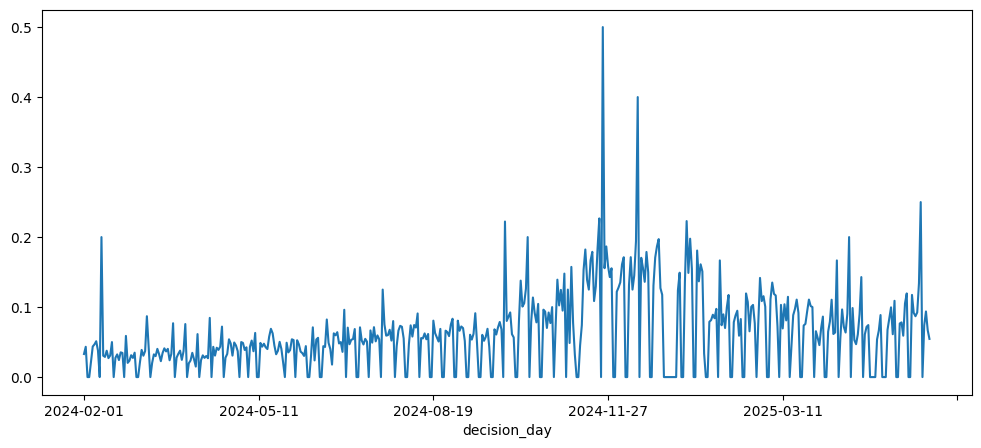

In [ ]:
daily = (
    train.groupby("decision_day")
    ["target_value"]
    .mean()
)

daily.plot(figsize=(12,5))

In [ ]:
print(train["decision_day"].min())
print(train["decision_day"].max())

print(test["decision_day"].min())
print(test["decision_day"].max())

2024-02-01
2025-06-05
2025-06-05
2025-12-01


# время

In [ ]:
train_time = train.copy()

train_time["decision_day"] = pd.to_datetime(
    train_time["decision_day"]
)

train_time["year"] = train_time["decision_day"].dt.year
train_time["month"] = train_time["decision_day"].dt.month
train_time["quarter"] = train_time["decision_day"].dt.quarter
train_time["dayofweek"] = train_time["decision_day"].dt.dayofweek
train_time["weekday_name"] = train_time["decision_day"].dt.day_name()
train_time["weekofyear"] = train_time["decision_day"].dt.isocalendar().week.astype(int)
train_time["dayofmonth"] = train_time["decision_day"].dt.day
train_time["is_month_start"] = train_time["decision_day"].dt.is_month_start.astype(int)
train_time["is_month_end"] = train_time["decision_day"].dt.is_month_end.astype(int)

In [ ]:
weekday_stats = (
    train_time
    .groupby("weekday_name")
    .agg(
        n=("target_value", "size"),
        conversion=("target_value", "mean")
    )
    .sort_values("conversion", ascending=False)
)

weekday_stats

,n,conversion
weekday_name,,
Thursday,28954,0.063273
Tuesday,30847,0.061854
Wednesday,29049,0.061551
Friday,22871,0.061388
Saturday,2346,0.059676
Monday,30297,0.057828
Sunday,877,0.025086


In [ ]:
month_stats = (
    train_time
    .groupby(["year", "month"])
    .agg(
        n=("target_value", "size"),
        conversion=("target_value", "mean")
    )
    .reset_index()
)

month_stats

,year,month,n,conversion
0,2024,2,9743,0.031099
1,2024,3,14702,0.032785
2,2024,4,17306,0.034381
3,2024,5,17330,0.044201
4,2024,6,11926,0.048214
5,2024,7,12657,0.058624
6,2024,8,12039,0.063294
7,2024,9,12287,0.064296
8,2024,10,8247,0.094701
9,2024,11,3996,0.131381


In [ ]:
quarter_stats = (
    train_time
    .groupby(["year", "quarter"])
    .agg(
        n=("target_value", "size"),
        conversion=("target_value", "mean")
    )
    .reset_index()
)

quarter_stats

,year,quarter,n,conversion
0,2024,1,24445,0.032113
1,2024,2,46562,0.041579
2,2024,3,36983,0.062028
3,2024,4,15865,0.117050
4,2025,1,12665,0.101856
5,2025,2,8721,0.078431


In [ ]:
week_stats = (
    train_time
    .groupby("weekofyear")
    .agg(
        n=("target_value", "size"),
        conversion=("target_value", "mean")
    )
    .reset_index()
)

week_stats

,weekofyear,n,conversion
0,1,12,0.000000
1,2,239,0.129707
2,3,840,0.171429
3,4,939,0.135250
4,5,1602,0.073658
5,6,2535,0.060355
6,7,3792,0.045095
7,8,3695,0.051421
8,9,4169,0.048693
9,10,3657,0.053049


In [ ]:
time_analysis = train_time[
    [
        "decision_day",
        "year",
        "month",
        "quarter",
        "weekofyear",
        "dayofweek",
        "weekday_name",
        "dayofmonth",
        "is_month_start",
        "is_month_end",
        "target_value"
    ]
]

time_analysis.to_csv(
    "time_analysis.csv",
    index=False
)

print("saved time_analysis.csv")

saved time_analysis.csv


In [ ]:
daily_conversion = (
    train_time
    .groupby("decision_day")
    ["target_value"]
    .mean()
)

daily_count = (
    train_time
    .groupby("decision_day")
    ["target_value"]
    .count()
)

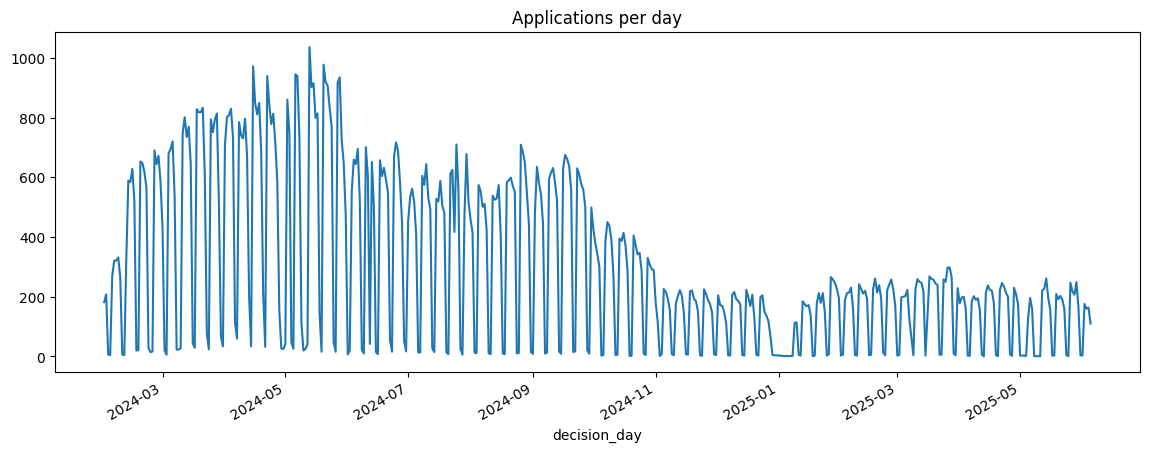

In [ ]:
plt.figure(figsize=(14,5))
daily_count.plot()
plt.title("Applications per day")
plt.show()

In [ ]:
import numpy as np
import pandas as pd

from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score

train = pd.read_csv("/content/train_apps.csv")
train = train.dropna(subset=["target_value"])

train["decision_day"] = pd.to_datetime(train["decision_day"])

train["year"] = train["decision_day"].dt.year
train["month"] = train["decision_day"].dt.month
train["quarter"] = train["decision_day"].dt.quarter
train["weekofyear"] = train["decision_day"].dt.isocalendar().week.astype(int)
train["dayofweek"] = train["decision_day"].dt.dayofweek

train["loan_to_max"] = (
    train["loan_amount_last"]
    / (train["overdraft_limit_max"] + 1)
)

train["loan_to_min"] = (
    train["loan_amount_last"]
    / (train["overdraft_limit_min"] + 1)
)

train["limit_gap"] = (
    train["overdraft_limit_max"]
    - train["overdraft_limit_min"]
)

train["activity_ratio"] = (
    train["sum_deb_ul_30"]
    / (train["sum_deb_ul_90"] + 1)
)

train["operations_ratio"] = (
    train["cnt_deb_ul_ip_30"]
    / (train["cnt_deb_ul_ip_90"] + 1)
)

train["activity_total"] = (
    train["count_all_corp_dashboard_events"]
    * train["p75_time_spent_minutes"]
)

train["avg_transfer_90"] = (
    train["sum_deb_ul_90"]
    / (train["cnt_deb_ul_ip_90"] + 1)
)

train["avg_transfer_30"] = (
    train["sum_deb_ul_30"]
    / (train["cnt_deb_ul_ip_30"] + 1)
)

train["loan_coverage"] = (
    train["overdraft_limit_max"]
    - train["loan_amount_last"]
)

train["loan_coverage_ratio"] = (
    train["overdraft_limit_max"]
    / (train["loan_amount_last"] + 1)
)

train["balance_to_loan"] = (
    train["balance_rur_amt_30_min"]
    / (train["loan_amount_last"] + 1)
)

train["time_per_event"] = (
    train["p75_time_spent_minutes"]
    / (train["count_all_corp_dashboard_events"] + 1)
)

drop_cols = [
    "front_id",
    "cb_rate",
    "decision_day",
    "overdraft_app_term_max_360",
    "loan_rev_max_start_non_fin",
    "sum_deb_investment_90",
    "loan_rev_min_start_fin"
]

existing_drop = [
    col for col in drop_cols
    if col in train.columns
]

train = train.drop(columns=existing_drop)
train = train.sort_values(
    by=["year", "month", "weekofyear"]
)

split_idx = int(len(train) * 0.8)

train_part = train.iloc[:split_idx]
valid_part = train.iloc[split_idx:]

X_train = train_part.drop(columns=["target_value"])
y_train = train_part["target_value"]

X_valid = valid_part.drop(columns=["target_value"])
y_valid = valid_part["target_value"]

cat_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

for col in cat_features:

    X_train[col] = (
        X_train[col]
        .fillna("missing")
        .astype(str)
    )

    X_valid[col] = (
        X_valid[col]
        .fillna("missing")
        .astype(str)
    )





model = CatBoostClassifier(
    iterations=1500,
    depth=6,
    learning_rate=0.03,
    eval_metric="AUC",
    random_seed=42,
    verbose=False
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features
)
pred = model.predict_proba(X_valid)[:, 1]

auc = roc_auc_score(
    y_valid,
    pred
)

print("TIME SPLIT ROC-AUC =", auc)

TIME SPLIT ROC-AUC = 0.7574589025478669


In [ ]:
results = []

param_grid = {
    "depth": [4, 5, 6],
    "learning_rate": [0.02, 0.03, 0.05],
    "l2_leaf_reg": [3, 10, 20]
}

total = (
    len(param_grid["depth"])
    * len(param_grid["learning_rate"])
    * len(param_grid["l2_leaf_reg"])
)

counter = 1

for depth, lr, l2 in product(
    param_grid["depth"],
    param_grid["learning_rate"],
    param_grid["l2_leaf_reg"]
):

    print(
        f"[{counter}/{total}] "
        f"depth={depth}, "
        f"lr={lr}, "
        f"l2={l2}"
    )

    model = CatBoostClassifier(
        iterations=2000,
        depth=depth,
        learning_rate=lr,
        l2_leaf_reg=l2,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=42,
        verbose=False
    )

    model.fit(
        X_train,
        y_train,
        cat_features=cat_features
    )

    pred = model.predict_proba(X_valid)[:, 1]

    auc = roc_auc_score(
        y_valid,
        pred
    )

    results.append({
        "depth": depth,
        "learning_rate": lr,
        "l2_leaf_reg": l2,
        "auc": auc
    })

    print("AUC =", round(auc, 6))
    print()

    counter += 1

results_df = (
    pd.DataFrame(results)
    .sort_values("auc", ascending=False)
)

print("\nTOP 10 CONFIGS\n")
print(results_df.head(10))

best_params = results_df.iloc[0]

print("\nBEST CONFIG:")
print(best_params)

[1/27] depth=4, lr=0.02, l2=3
AUC = 0.758425

[2/27] depth=4, lr=0.02, l2=10
AUC = 0.758794

[3/27] depth=4, lr=0.02, l2=20
AUC = 0.758977

[4/27] depth=4, lr=0.03, l2=3
AUC = 0.758015

[5/27] depth=4, lr=0.03, l2=10
AUC = 0.758022

[6/27] depth=4, lr=0.03, l2=20
AUC = 0.757993

[7/27] depth=4, lr=0.05, l2=3
AUC = 0.755316

[8/27] depth=4, lr=0.05, l2=10
AUC = 0.754592

[9/27] depth=4, lr=0.05, l2=20
AUC = 0.756715

[10/27] depth=5, lr=0.02, l2=3
AUC = 0.758108

[11/27] depth=5, lr=0.02, l2=10
AUC = 0.758232

[12/27] depth=5, lr=0.02, l2=20
AUC = 0.758978

[13/27] depth=5, lr=0.03, l2=3
AUC = 0.755897

[14/27] depth=5, lr=0.03, l2=10
AUC = 0.756322

[15/27] depth=5, lr=0.03, l2=20
AUC = 0.75787

[16/27] depth=5, lr=0.05, l2=3
AUC = 0.751979

[17/27] depth=5, lr=0.05, l2=10
AUC = 0.754588

[18/27] depth=5, lr=0.05, l2=20
AUC = 0.754207

[19/27] depth=6, lr=0.02, l2=3
AUC = 0.757735

[20/27] depth=6, lr=0.02, l2=10
AUC = 0.75716

[21/27] depth=6, lr=0.02, l2=20
AUC = 0.758569

[22/27] de

In [ ]:
train = pd.read_csv("train_apps.csv")
test = pd.read_csv("test_apps.csv")

train = train.dropna(subset=["target_value"])
for df in [train, test]:

    df["decision_day"] = pd.to_datetime(df["decision_day"])

    # time features
    df["year"] = df["decision_day"].dt.year
    df["month"] = df["decision_day"].dt.month
    df["quarter"] = df["decision_day"].dt.quarter
    df["weekofyear"] = df["decision_day"].dt.isocalendar().week.astype(int)
    df["dayofweek"] = df["decision_day"].dt.dayofweek


    df["loan_to_max"] = (
        df["loan_amount_last"]
        / (df["overdraft_limit_max"] + 1)
    )

    df["loan_to_min"] = (
        df["loan_amount_last"]
        / (df["overdraft_limit_min"] + 1)
    )

    df["limit_gap"] = (
        df["overdraft_limit_max"]
        - df["overdraft_limit_min"]
    )

    df["activity_ratio"] = (
        df["sum_deb_ul_30"]
        / (df["sum_deb_ul_90"] + 1)
    )

    df["operations_ratio"] = (
        df["cnt_deb_ul_ip_30"]
        / (df["cnt_deb_ul_ip_90"] + 1)
    )

    df["activity_total"] = (
        df["count_all_corp_dashboard_events"]
        * df["p75_time_spent_minutes"]
    )

    df["avg_transfer_90"] = (
        df["sum_deb_ul_90"]
        / (df["cnt_deb_ul_ip_90"] + 1)
    )

    df["avg_transfer_30"] = (
        df["sum_deb_ul_30"]
        / (df["cnt_deb_ul_ip_30"] + 1)
    )

test_ids = test["front_id"]

drop_cols = [
    "front_id",
    "cb_rate",
    "decision_day",
    "overdraft_app_term_max_360",
    "loan_rev_max_start_non_fin",
    "loan_rev_min_start_fin",
    "sum_deb_investment_90"
]

for df in [train, test]:

    existing = [c for c in drop_cols if c in df.columns]

    df.drop(columns=existing, inplace=True)

X_train = train.drop(columns=["target_value"])
y_train = train["target_value"]

X_test = test.copy()

cat_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

for col in cat_features:

    X_train[col] = (
        X_train[col]
        .fillna("missing")
        .astype(str)
    )

    X_test[col] = (
        X_test[col]
        .fillna("missing")
        .astype(str)
    )






model = CatBoostClassifier(
    iterations=2000,
    depth=5,
    learning_rate=0.02,
    l2_leaf_reg=20,
    eval_metric="AUC",
    random_seed=42,
    verbose=False
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

pred = model.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    "front_id": test_ids,
    "target_value": pred
})

submission.to_csv(
    "submission_final.csv",
    index=False
)

print(submission.head())

In [ ]:
submission["target_value"] = submission["target_value"].round(10)
submission.to_csv(
    "submission_final.csv",
    index=False
)